# UV Index Forecasting with Varying Lag Windows
## Section 4.2 — Lag Window Comparison (Colombo, Sri Lanka)

**Models:** Random Forest (RF), XGBoost (XGB), Feedforward Neural Network (FNN), LSTM, CNN  
**Lag Windows:** Short-term (12 lags), Medium-term (24 lags), Long-term (36 lags)

> **Checkpoint system:** Each model cell saves results + optimal hyperparameters to `checkpoint/` after completion.  
> Re-running a cell will **skip** already-computed results — you will not lose progress.

## Cell 1 — Install & Imports

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'statsmodels', 'tabulate', 'optuna', 'xgboost',
                'gdown', 'tensorflow', '--quiet'], check=False)

import os, warnings, random, pickle
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from optuna.samplers import TPESampler

import xgboost as xgb

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.optimizers import Adam

from tabulate import tabulate
from IPython.display import display

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Checkpoint directory ─────────────────────────────────────────────────────
os.makedirs('checkpoint', exist_ok=True)

print('✅ Imports OK  |  TF:', tf.__version__)

✅ Imports OK  |  TF: 2.19.0


## Cell 2 — Data Loading

In [2]:
import pandas as pd

# Google Drive File ID (from your new link)
file_id = "1El7t3dWhDydV8JNbRqxrx3RfVKHNw4IF"

# Direct download link
download_url = f"https://drive.google.com/uc?id={file_id}"

# Load data (assumes it's a CSV file)
df = pd.read_csv(download_url)

# Backup
df_backup = df.copy()

df.head()

,YEAR,MO,DY,HR,WD10M,T2M,SZA,ALLSKY_SFC_UV_INDEX,RH2M,PRECTOTCORR,WS10M,PS
0,2018,1,1,0,19.4,25.21,90.0,0.0,85.21,0.0,3.40,100.88
1,2018,1,1,1,13.2,25.11,90.0,0.0,85.30,0.0,3.29,100.79
2,2018,1,1,2,8.8,25.01,90.0,0.0,85.46,0.0,3.20,100.73
3,2018,1,1,3,7.5,24.94,90.0,0.0,85.51,0.0,3.13,100.72
4,2018,1,1,4,10.1,24.91,90.0,0.0,85.40,0.0,3.07,100.76


## Cell 3 — Preprocessing

In [3]:
df['DateTime'] = pd.to_datetime(
    df[['YEAR','MO','DY','HR']].rename(
        columns={'YEAR':'year','MO':'month','DY':'day','HR':'hour'}
    )
)
df = df.set_index('DateTime').drop(columns=['YEAR','MO','DY','HR'])

def get_monsoon_season(month):
    if month in [12, 1, 2]:    return 'Northeast Monsoon'
    elif month in [3, 4]:      return 'Inter-Monsoon 1'
    elif month in [5,6,7,8,9]: return 'Southwest Monsoon'
    else:                      return 'Inter-Monsoon 2'

df['monsoon_season'] = df.index.month.map(get_monsoon_season)
season_order = ['Northeast Monsoon','Inter-Monsoon 1','Southwest Monsoon','Inter-Monsoon 2']
df['monsoon_season'] = pd.Categorical(df['monsoon_season'], categories=season_order, ordered=True)

df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
df = df[(df.index.hour >= 6) & (df.index.hour <= 17)]

df['ALLSKY_SFC_UV_INDEX'] = df['ALLSKY_SFC_UV_INDEX'].replace(-999.0, np.nan)
df['ALLSKY_SFC_UV_INDEX'] = df['ALLSKY_SFC_UV_INDEX'].interpolate(method='polynomial', order=3)

monsoon_dummies = pd.get_dummies(df['monsoon_season'], prefix='monsoon', drop_first=True)
df = pd.concat([df, monsoon_dummies], axis=1).drop(columns=['monsoon_season'])

df['WD10M_sin'] = np.sin(np.deg2rad(df['WD10M']))
df['WD10M_cos'] = np.cos(np.deg2rad(df['WD10M']))
df = df.drop(columns=['WD10M'])
df = df.rename(columns={'ALLSKY_SFC_UV_INDEX': 'UV_INDEX'})

original_df = df.copy()
print(f'Preprocessed shape: {df.shape}')

Preprocessed shape: (26292, 14)


## Cell 4 — Helper Functions & Dataset Construction

In [4]:
# ── Tuning budget (reduced for speed) ───────────────────────────────────────
N_TRIALS = 15
N_SPLITS = 3

# ── Metrics ──────────────────────────────────────────────────────────────────
def evaluate_metrics(y_true, y_pred, label=''):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100
    r2   = r2_score(y_true, y_pred)
    if label:
        print(f'{label:35s}  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}')
    return mse, rmse, mae, mape, r2

# ── Lag dataset builder ──────────────────────────────────────────────────────
def build_lag_dataset(dataframe, target_col, n_lags):
    lag_dict = {f'{target_col}_lag_{k}': dataframe[target_col].shift(k)
                for k in range(1, n_lags + 1)}
    lag_df = pd.DataFrame(lag_dict, index=dataframe.index)
    lag_df[target_col] = dataframe[target_col]
    return lag_df.dropna()

# ── Chronological 80/20 split ────────────────────────────────────────────────
def chronological_split(lag_df, target_col):
    split_idx  = int(len(lag_df) * 0.8)
    split_date = lag_df.index[split_idx]
    train = lag_df[lag_df.index < split_date]
    test  = lag_df[lag_df.index >= split_date]
    return (train.drop(columns=[target_col]), train[target_col],
            test.drop(columns=[target_col]),  test[target_col], split_date)

# ── Checkpoint helpers ───────────────────────────────────────────────────────
def ckpt_path(window_name, model_name):
    safe = window_name.strip().replace(' ', '_').replace('(', '').replace(')', '')
    return f'checkpoint/{safe}__{model_name}.pkl'

def save_ckpt(window_name, model_name, metrics, model, y_test, y_pred, best_params=None):
    path = ckpt_path(window_name, model_name)
    with open(path, 'wb') as f:
        pickle.dump({'metrics': metrics, 'model': model,
                     'y_test': y_test, 'y_pred': y_pred,
                     'best_params': best_params}, f)

def load_ckpt(window_name, model_name):
    path = ckpt_path(window_name, model_name)
    if os.path.exists(path):
        with open(path, 'rb') as f:
            return pickle.load(f)
    return None

# ── Lag windows ──────────────────────────────────────────────────────────────
LAG_WINDOWS = {
    'Short-term - One Day   (12 lags)' : 12,
    'Medium-term - Two Day  (24 lags)' : 24,
    'Long-term  - Three Day   (36 lags)' : 36,
}

datasets = {}
for name, n_lags in LAG_WINDOWS.items():
    lag_df = build_lag_dataset(original_df, 'UV_INDEX', n_lags)
    X_tr, y_tr, X_ts, y_ts, split_date = chronological_split(lag_df, 'UV_INDEX')
    datasets[name] = dict(n_lags=n_lags, lag_df=lag_df,
                          X_train=X_tr, y_train=y_tr,
                          X_test=X_ts,  y_test=y_ts,
                          split_date=split_date)
    print(f'{name}  |  train={len(X_tr):,}  test={len(X_ts):,}  split={split_date.date()}')

window_labels = list(LAG_WINDOWS.keys())
model_labels  = ['RF', 'XGB', 'FNN', 'LSTM', 'CNN']
print('\n✅ Datasets ready.')

Short-term - One Day   (12 lags)  |  train=21,024  test=5,256  split=2022-10-20
Medium-term - Two Day  (24 lags)  |  train=21,014  test=5,254  split=2022-10-20
Long-term  - Three Day   (36 lags)  |  train=21,004  test=5,252  split=2022-10-20

✅ Datasets ready.


---
## Cell 5 — Train: Random Forest (RF)
> Saves results + optimal hyperparameters to `checkpoint/`. Re-run safely — already-done combos are skipped.

In [5]:
def train_rf(X_train, y_train, X_test, y_test):
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)

    def objective(trial):
        m = RandomForestRegressor(
            n_estimators      = trial.suggest_int('n_estimators', 50, 150, step=50),
            max_depth         = trial.suggest_categorical('max_depth', [None, 10, 20]),
            min_samples_split = trial.suggest_int('min_samples_split', 2, 6),
            min_samples_leaf  = trial.suggest_int('min_samples_leaf', 1, 4),
            max_features      = trial.suggest_categorical('max_features', ['sqrt', 'log2']),
            random_state=SEED, n_jobs=-1,
        )
        scores = [mean_squared_error(y_train.iloc[val],
                  m.fit(X_train.iloc[tr], y_train.iloc[tr]).predict(X_train.iloc[val]))
                  for tr, val in tscv.split(X_train)]
        return np.mean(scores)

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=SEED))
    study.optimize(objective, n_trials=N_TRIALS)
    best = RandomForestRegressor(**study.best_params, random_state=SEED, n_jobs=-1)
    best.fit(X_train, y_train)
    y_pred = best.predict(X_test)
    return evaluate_metrics(y_test, y_pred), best, y_pred, study.best_params

MODEL_NAME = 'RF'
for window_name, ds in datasets.items():
    ck = load_ckpt(window_name, MODEL_NAME)
    if ck:
        print(f'[SKIP — loaded] {window_name.strip():40s}  RMSE={ck["metrics"][1]:.4f}  R²={ck["metrics"][4]:.4f}')
        continue
    print(f'[TRAINING]      {window_name.strip():40s} ...', end=' ', flush=True)
    metrics, model, y_pred, best_params = train_rf(
        ds['X_train'], ds['y_train'], ds['X_test'], ds['y_test'])
    save_ckpt(window_name, MODEL_NAME, metrics, model, ds['y_test'], y_pred, best_params)
    print(f'RMSE={metrics[1]:.4f}  MAE={metrics[2]:.4f}  R²={metrics[4]:.4f}')
    print(f'  Best params: {best_params}')

print('\n✅ RF done.')

[TRAINING]      Short-term - One Day   (12 lags)         ... RMSE=0.4846  MAE=0.2598  R²=0.9801
  Best params: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
[TRAINING]      Medium-term - Two Day  (24 lags)         ... RMSE=0.5163  MAE=0.2800  R²=0.9774
  Best params: {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
[TRAINING]      Long-term  - Three Day   (36 lags)       ... RMSE=0.5190  MAE=0.2829  R²=0.9772
  Best params: {'n_estimators': 150, 'max_depth': None, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt'}

✅ RF done.


---
## Cell 6 — Train: XGBoost (XGB)

In [6]:
def train_xgb(X_train, y_train, X_test, y_test):
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)

    def objective(trial):
        m = xgb.XGBRegressor(
            n_estimators     = trial.suggest_int('n_estimators', 50, 200, step=50),
            max_depth        = trial.suggest_int('max_depth', 3, 8),
            learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            subsample        = trial.suggest_float('subsample', 0.6, 1.0),
            min_child_weight = trial.suggest_int('min_child_weight', 1, 5),
            objective='reg:squarederror', random_state=SEED, verbosity=0,
        )
        scores = [mean_squared_error(y_train.iloc[val],
                  m.fit(X_train.iloc[tr], y_train.iloc[tr]).predict(X_train.iloc[val]))
                  for tr, val in tscv.split(X_train)]
        return np.mean(scores)

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=SEED))
    study.optimize(objective, n_trials=N_TRIALS)
    best = xgb.XGBRegressor(**study.best_params, random_state=SEED, verbosity=0)
    best.fit(X_train, y_train)
    y_pred = best.predict(X_test)
    return evaluate_metrics(y_test, y_pred), best, y_pred, study.best_params

MODEL_NAME = 'XGB'
for window_name, ds in datasets.items():
    ck = load_ckpt(window_name, MODEL_NAME)
    if ck:
        print(f'[SKIP — loaded] {window_name.strip():40s}  RMSE={ck["metrics"][1]:.4f}  R²={ck["metrics"][4]:.4f}')
        continue
    print(f'[TRAINING]      {window_name.strip():40s} ...', end=' ', flush=True)
    metrics, model, y_pred, best_params = train_xgb(
        ds['X_train'], ds['y_train'], ds['X_test'], ds['y_test'])
    save_ckpt(window_name, MODEL_NAME, metrics, model, ds['y_test'], y_pred, best_params)
    print(f'RMSE={metrics[1]:.4f}  MAE={metrics[2]:.4f}  R²={metrics[4]:.4f}')
    print(f'  Best params: {best_params}')

print('\n✅ XGB done.')

[TRAINING]      Short-term - One Day   (12 lags)         ... RMSE=0.4995  MAE=0.2733  R²=0.9789
  Best params: {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.02964033652082882, 'subsample': 0.6071847502459279, 'min_child_weight': 2}
[TRAINING]      Medium-term - Two Day  (24 lags)         ... RMSE=0.5106  MAE=0.2713  R²=0.9779
  Best params: {'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.09725993945190982, 'subsample': 0.681202892785981, 'min_child_weight': 4}
[TRAINING]      Long-term  - Three Day   (36 lags)       ... RMSE=0.5097  MAE=0.2722  R²=0.9780
  Best params: {'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.10081853902880024, 'subsample': 0.6207679281222178, 'min_child_weight': 2}

✅ XGB done.


---
## Cell 7 — Train: Feedforward Neural Network (FNN)

In [7]:
def train_fnn(X_train, y_train, X_test, y_test):
    scaler = StandardScaler()
    Xtr_s  = scaler.fit_transform(X_train)
    Xts_s  = scaler.transform(X_test)
    tscv   = TimeSeriesSplit(n_splits=N_SPLITS)

    def objective(trial):
        n_layers = trial.suggest_int('n_layers', 1, 2)
        hls = tuple(trial.suggest_int(f'units_l{i}', 32, 128, step=32)
                    for i in range(n_layers))
        m = MLPRegressor(
            hidden_layer_sizes=hls,
            activation=trial.suggest_categorical('activation', ['relu', 'tanh']),
            alpha=trial.suggest_float('alpha', 1e-4, 1e-2, log=True),
            max_iter=500, random_state=SEED, solver='adam',
        )
        scores = [mean_squared_error(y_train.iloc[val],
                  m.fit(Xtr_s[tr], y_train.iloc[tr]).predict(Xtr_s[val]))
                  for tr, val in tscv.split(Xtr_s)]
        return np.mean(scores)

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=SEED))
    study.optimize(objective, n_trials=N_TRIALS, timeout=300)
    bp  = study.best_params
    hls = tuple(bp[f'units_l{i}'] for i in range(bp['n_layers']))
    best = MLPRegressor(hidden_layer_sizes=hls, activation=bp['activation'],
                        alpha=bp['alpha'], max_iter=500, random_state=SEED, solver='adam')
    best.fit(Xtr_s, y_train)
    y_pred = best.predict(Xts_s)
    return evaluate_metrics(y_test, y_pred), best, y_pred, study.best_params

MODEL_NAME = 'FNN'
for window_name, ds in datasets.items():
    ck = load_ckpt(window_name, MODEL_NAME)
    if ck:
        print(f'[SKIP — loaded] {window_name.strip():40s}  RMSE={ck["metrics"][1]:.4f}  R²={ck["metrics"][4]:.4f}')
        continue
    print(f'[TRAINING]      {window_name.strip():40s} ...', end=' ', flush=True)
    metrics, model, y_pred, best_params = train_fnn(
        ds['X_train'], ds['y_train'], ds['X_test'], ds['y_test'])
    save_ckpt(window_name, MODEL_NAME, metrics, model, ds['y_test'], y_pred, best_params)
    print(f'RMSE={metrics[1]:.4f}  MAE={metrics[2]:.4f}  R²={metrics[4]:.4f}')
    print(f'  Best params: {best_params}')

print('\n✅ FNN done.')

[TRAINING]      Short-term - One Day   (12 lags)         ... RMSE=0.4901  MAE=0.2856  R²=0.9797
  Best params: {'n_layers': 2, 'units_l0': 128, 'units_l1': 32, 'activation': 'relu', 'alpha': 0.00010352882298746124}
[TRAINING]      Medium-term - Two Day  (24 lags)         ... RMSE=0.4917  MAE=0.2838  R²=0.9795
  Best params: {'n_layers': 1, 'units_l0': 64, 'activation': 'relu', 'alpha': 0.0003823475224675188}
[TRAINING]      Long-term  - Three Day   (36 lags)       ... RMSE=0.4831  MAE=0.2740  R²=0.9803
  Best params: {'n_layers': 1, 'units_l0': 64, 'activation': 'relu', 'alpha': 0.0003823475224675188}

✅ FNN done.


---
## Cell 8 — Train: LSTM

In [8]:
def train_lstm(X_train, y_train, X_test, y_test):
    scaler = StandardScaler()
    Xtr_s  = scaler.fit_transform(X_train).reshape(-1, 1, X_train.shape[1])
    Xts_s  = scaler.transform(X_test).reshape(-1, 1, X_test.shape[1])
    ytr    = y_train.values
    yts    = y_test.values
    tscv   = TimeSeriesSplit(n_splits=N_SPLITS)

    def objective(trial):
        units  = trial.suggest_int('units', 20, 80, step=20)
        dr     = trial.suggest_float('dropout_rate', 0.1, 0.4)
        lr     = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
        bs     = trial.suggest_categorical('batch_size', [32, 64])
        epochs = trial.suggest_int('epochs', 20, 50, step=10)
        scores = []
        for tr, val in tscv.split(Xtr_s):
            m = Sequential([LSTM(units, input_shape=(1, X_train.shape[1])),
                            Dropout(dr), Dense(1)])
            m.compile(loss='mse', optimizer=Adam(lr))
            m.fit(Xtr_s[tr], ytr[tr], epochs=epochs, batch_size=bs,
                  verbose=0, shuffle=False)
            preds  = m.predict(Xtr_s[val], verbose=0).flatten()
            actual = ytr[val] if len(val) == len(preds) else ytr[-len(preds):]
            scores.append(mean_squared_error(actual, preds))
        return np.mean(scores)

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=SEED))
    study.optimize(objective, n_trials=N_TRIALS, timeout=600)
    bp   = study.best_trial.params
    best = Sequential([LSTM(bp['units'], input_shape=(1, X_train.shape[1])),
                       Dropout(bp['dropout_rate']), Dense(1)])
    best.compile(loss='mse', optimizer=Adam(bp['learning_rate']))
    best.fit(Xtr_s, ytr, epochs=bp['epochs'], batch_size=bp['batch_size'],
             verbose=0, shuffle=False)
    y_pred = best.predict(Xts_s, verbose=0).flatten()
    return evaluate_metrics(yts, y_pred), best, y_pred, bp

MODEL_NAME = 'LSTM'
for window_name, ds in datasets.items():
    ck = load_ckpt(window_name, MODEL_NAME)
    if ck:
        print(f'[SKIP — loaded] {window_name.strip():40s}  RMSE={ck["metrics"][1]:.4f}  R²={ck["metrics"][4]:.4f}')
        continue
    print(f'[TRAINING]      {window_name.strip():40s} ...', end=' ', flush=True)
    metrics, model, y_pred, best_params = train_lstm(
        ds['X_train'], ds['y_train'], ds['X_test'], ds['y_test'])
    save_ckpt(window_name, MODEL_NAME, metrics, model, ds['y_test'], y_pred, best_params)
    print(f'RMSE={metrics[1]:.4f}  MAE={metrics[2]:.4f}  R²={metrics[4]:.4f}')
    print(f'  Best params: {best_params}')

print('\n✅ LSTM done.')

[TRAINING]      Short-term - One Day   (12 lags)         ... RMSE=0.5149  MAE=0.3220  R²=0.9776
  Best params: {'units': 40, 'dropout_rate': 0.12930163420191518, 'learning_rate': 0.0023359635026261607, 'batch_size': 32, 'epochs': 30}
[TRAINING]      Medium-term - Two Day  (24 lags)         ... RMSE=0.5096  MAE=0.3265  R²=0.9780
  Best params: {'units': 40, 'dropout_rate': 0.12930163420191518, 'learning_rate': 0.0023359635026261607, 'batch_size': 32, 'epochs': 30}
[TRAINING]      Long-term  - Three Day   (36 lags)       ... RMSE=0.4999  MAE=0.2908  R²=0.9789
  Best params: {'units': 80, 'dropout_rate': 0.16370173320348286, 'learning_rate': 0.0002310201887845295, 'batch_size': 64, 'epochs': 40}

✅ LSTM done.


---
## Cell 9 — Train: CNN

In [9]:
def train_cnn(X_train, y_train, X_test, y_test):
    scaler = StandardScaler()
    Xtr_s  = scaler.fit_transform(X_train).reshape(-1, X_train.shape[1], 1)
    Xts_s  = scaler.transform(X_test).reshape(-1, X_test.shape[1], 1)
    ytr    = y_train.values
    yts    = y_test.values
    tscv   = TimeSeriesSplit(n_splits=N_SPLITS)

    def build(filters, ks, lr):
        m = Sequential([
            Conv1D(filters, kernel_size=min(ks, X_train.shape[1]),
                   activation='relu', padding='same',
                   input_shape=(X_train.shape[1], 1)),
            MaxPooling1D(pool_size=1), Flatten(),
            Dense(32, activation='relu'), Dense(1),
        ])
        m.compile(optimizer=Adam(lr), loss='mse')
        return m

    def objective(trial):
        filters = trial.suggest_int('filters', 32, 96, step=32)
        ks      = trial.suggest_int('kernel_size', 1, 3)
        lr      = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
        bs      = trial.suggest_categorical('batch_size', [16, 32])
        epochs  = trial.suggest_int('epochs', 10, 30, step=10)
        scores  = []
        for tr, val in tscv.split(Xtr_s):
            m = build(filters, ks, lr)
            m.fit(Xtr_s[tr], ytr[tr], epochs=epochs, batch_size=bs, verbose=0)
            scores.append(m.evaluate(Xtr_s[val], ytr[val], verbose=0))
        return np.mean(scores)

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=SEED))
    study.optimize(objective, n_trials=N_TRIALS, timeout=600)
    bp   = study.best_trial.params
    best = build(bp['filters'], bp['kernel_size'], bp['lr'])
    best.fit(Xtr_s, ytr, epochs=bp['epochs'], batch_size=bp['batch_size'], verbose=0)
    y_pred = best.predict(Xts_s, verbose=0).flatten()
    return evaluate_metrics(yts, y_pred), best, y_pred, bp

MODEL_NAME = 'CNN'
for window_name, ds in datasets.items():
    ck = load_ckpt(window_name, MODEL_NAME)
    if ck:
        print(f'[SKIP — loaded] {window_name.strip():40s}  RMSE={ck["metrics"][1]:.4f}  R²={ck["metrics"][4]:.4f}')
        continue
    print(f'[TRAINING]      {window_name.strip():40s} ...', end=' ', flush=True)
    metrics, model, y_pred, best_params = train_cnn(
        ds['X_train'], ds['y_train'], ds['X_test'], ds['y_test'])
    save_ckpt(window_name, MODEL_NAME, metrics, model, ds['y_test'], y_pred, best_params)
    print(f'RMSE={metrics[1]:.4f}  MAE={metrics[2]:.4f}  R²={metrics[4]:.4f}')
    print(f'  Best params: {best_params}')

print('\n✅ CNN done.')

[TRAINING]      Short-term - One Day   (12 lags)         ... RMSE=0.5044  MAE=0.2961  R²=0.9785
  Best params: {'filters': 32, 'kernel_size': 3, 'lr': 0.00032927591344236165, 'batch_size': 16, 'epochs': 20}
[TRAINING]      Medium-term - Two Day  (24 lags)         ... RMSE=0.4877  MAE=0.2748  R²=0.9799
  Best params: {'filters': 32, 'kernel_size': 3, 'lr': 0.0015930522616241021, 'batch_size': 16, 'epochs': 30}
[TRAINING]      Long-term  - Three Day   (36 lags)       ... RMSE=0.4810  MAE=0.2606  R²=0.9804
  Best params: {'filters': 64, 'kernel_size': 1, 'lr': 0.0016738085788752138, 'batch_size': 32, 'epochs': 20}

✅ CNN done.


---
## Cell 10 — Load All Checkpoints → Rebuild Results Dict
> Run this cell before any visualisation. It reconstructs `results` and `predictions` from disk.

In [ ]:
results     = {}
predictions = {}

missing = []
for window_name in window_labels:
    results[window_name]     = {}
    predictions[window_name] = {}
    for model_name in model_labels:
        ck = load_ckpt(window_name, model_name)
        if ck:
            results[window_name][model_name]     = ck['metrics']
            predictions[window_name][model_name] = (ck['y_test'], ck['y_pred'])
            print(f'[OK]      {window_name.strip():40s}  {model_name:5s}  RMSE={ck["metrics"][1]:.4f}')
        else:
            missing.append((window_name, model_name))
            print(f'[MISSING] {window_name.strip():40s}  {model_name}')

if missing:
    print(f'\n⚠️  {len(missing)} combination(s) not yet trained — run their cells first.')
else:
    print('\n✅ All checkpoints loaded.')

---
## Cell 11 — Optimal Hyperparameters (All Models × All Windows)
> Prints a full parameter table and exports `Table_OptimalParams_AllModels.csv`

In [11]:
print('=' * 72)
print('   OPTIMAL HYPERPARAMETERS — All Models × All Lag Windows')
print('=' * 72)

param_rows   = []
table_rows   = []

for model_name in model_labels:
    print(f'\n{"-"*72}')
    print(f'  MODEL: {model_name}')
    print(f'{"-"*72}')
    for window_name in window_labels:
        ck = load_ckpt(window_name, model_name)
        if ck and ck.get('best_params'):
            params = ck['best_params']
            rmse   = ck['metrics'][1]
            mae    = ck['metrics'][2]
            r2     = ck['metrics'][4]
            print(f'\n  Window : {window_name.strip()}')
            print(f'  RMSE   : {rmse:.4f}   MAE : {mae:.4f}   R² : {r2:.4f}')
            print(f'  Optimal Parameters:')
            for k, v in params.items():
                print(f'    {k:<28s} = {v}')
            # Collect for tabulate
            for k, v in params.items():
                table_rows.append([model_name, window_name.strip(), k, v,
                                   f'{rmse:.4f}', f'{mae:.4f}', f'{r2:.4f}'])
            # Collect for CSV
            row = {'Model': model_name, 'Window': window_name.strip(),
                   'RMSE': round(rmse, 4), 'MAE': round(mae, 4), 'R2': round(r2, 4)}
            row.update({k: v for k, v in params.items()})
            param_rows.append(row)
        else:
            print(f'\n  Window : {window_name.strip()}')
            print(f'  [No params saved — re-run the model cell to regenerate]')

# ── Pretty tabulate summary ───────────────────────────────────────────────────
print('\n\n' + '=' * 72)
print('  SUMMARY TABLE')
print('=' * 72)
if table_rows:
    print(tabulate(table_rows,
                   headers=['Model', 'Window', 'Parameter', 'Value', 'RMSE', 'MAE', 'R²'],
                   tablefmt='grid'))

# ── Export to CSV ─────────────────────────────────────────────────────────────
if param_rows:
    params_df = pd.DataFrame(param_rows)
    params_df.to_csv('Table_OptimalParams_AllModels.csv', index=False)
    print('\n✅ Saved → Table_OptimalParams_AllModels.csv')
    display(params_df)

   OPTIMAL HYPERPARAMETERS — All Models × All Lag Windows

------------------------------------------------------------------------
  MODEL: RF
------------------------------------------------------------------------

  Window : Short-term - One Day   (12 lags)
  RMSE   : 0.4846   MAE : 0.2598   R² : 0.9801
  Optimal Parameters:
    n_estimators                 = 100
    max_depth                    = None
    min_samples_split            = 4
    min_samples_leaf             = 1
    max_features                 = sqrt

  Window : Medium-term - Two Day  (24 lags)
  RMSE   : 0.5163   MAE : 0.2800   R² : 0.9774
  Optimal Parameters:
    n_estimators                 = 100
    max_depth                    = None
    min_samples_split            = 4
    min_samples_leaf             = 1
    max_features                 = sqrt

  Window : Long-term  - Three Day   (36 lags)
  RMSE   : 0.5190   MAE : 0.2829   R² : 0.9772
  Optimal Parameters:
    n_estimators                 = 150
    max_depth 

,Model,Window,RMSE,MAE,R2,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,...,units_l1,activation,alpha,units,dropout_rate,batch_size,epochs,filters,kernel_size,lr
0,RF,Short-term - One Day (12 lags),0.4846,0.2598,0.9801,100.0,NaN,4.0,1.0,sqrt,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RF,Medium-term - Two Day (24 lags),0.5163,0.2800,0.9774,100.0,NaN,4.0,1.0,sqrt,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,RF,Long-term - Three Day (36 lags),0.5190,0.2829,0.9772,150.0,NaN,4.0,2.0,sqrt,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,XGB,Short-term - One Day (12 lags),0.4995,0.2733,0.9789,200.0,6.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,XGB,Medium-term - Two Day (24 lags),0.5106,0.2713,0.9779,100.0,7.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,XGB,Long-term - Three Day (36 lags),0.5097,0.2722,0.9780,100.0,7.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,FNN,Short-term - One Day (12 lags),0.4901,0.2856,0.9797,NaN,NaN,NaN,NaN,NaN,...,32.0,relu,0.000104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,FNN,Medium-term - Two Day (24 lags),0.4917,0.2838,0.9795,NaN,NaN,NaN,NaN,NaN,...,NaN,relu,0.000382,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,FNN,Long-term - Three Day (36 lags),0.4831,0.2740,0.9803,NaN,NaN,NaN,NaN,NaN,...,NaN,relu,0.000382,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,LSTM,Short-term - One Day (12 lags),0.5149,0.3220,0.9776,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,40.0,0.129302,32.0,30.0,NaN,NaN,NaN


---
## Cell 12 — Table 3: Performance Summary

In [12]:
rows = []
for window_name in window_labels:
    for model_name in model_labels:
        if model_name not in results.get(window_name, {}):
            continue
        m = results[window_name][model_name]
        rows.append([window_name.strip(), model_name,
                     f'{m[0]:.4f}', f'{m[1]:.4f}',
                     f'{m[2]:.4f}', f'{m[3]:.2f}', f'{m[4]:.4f}'])

headers = ['Window', 'Model', 'MSE', 'RMSE', 'MAE', 'MAPE (%)', 'R²']
print('Table 3. Model Performance by Lag Window — UV Index Forecasting (Colombo)\n')
print(tabulate(rows, headers=headers, tablefmt='grid'))

Table 3. Model Performance by Lag Window — UV Index Forecasting (Colombo)

+------------------------------------+---------+--------+--------+--------+-------------+--------+
| Window                             | Model   |    MSE |   RMSE |    MAE |    MAPE (%) |     R² |
+====================================+=========+========+========+========+=============+========+
| Short-term - One Day   (12 lags)   | RF      | 0.2349 | 0.4846 | 0.2598 | 3.45096e+06 | 0.9801 |
+------------------------------------+---------+--------+--------+--------+-------------+--------+
| Short-term - One Day   (12 lags)   | XGB     | 0.2495 | 0.4995 | 0.2733 | 1.98036e+07 | 0.9789 |
+------------------------------------+---------+--------+--------+--------+-------------+--------+
| Short-term - One Day   (12 lags)   | FNN     | 0.2402 | 0.4901 | 0.2856 | 1.34184e+07 | 0.9797 |
+------------------------------------+---------+--------+--------+--------+-------------+--------+
| Short-term - One Day   (12 lags)

## Cell 13 — Interactive Plotly Table

In [13]:
col_window = [r[0] for r in rows]
col_model  = [r[1] for r in rows]
col_mse    = [r[2] for r in rows]
col_rmse   = [r[3] for r in rows]
col_mae    = [r[4] for r in rows]
col_mape   = [r[5] for r in rows]
col_r2     = [r[6] for r in rows]

window_colors_map = {
    'Short-term - One Day   (12 lags)' : '#cce5ff',
    'Medium-term - Two Day  (24 lags)' : '#d4edda',
    'Long-term  - Three Day   (36 lags)' : '#fff3cd',
}
row_colors = [window_colors_map.get(w, 'white') for w in col_window]

fig_tbl = go.Figure(go.Table(
    columnwidth=[3, 1.5, 1.5, 1.5, 1.5, 1.8, 1.5],
    header=dict(
        values=['<b>Window</b>', '<b>Model</b>', '<b>MSE</b>',
                '<b>RMSE</b>', '<b>MAE</b>', '<b>MAPE (%)</b>', '<b>R²</b>'],
        fill_color='#343a40', font=dict(color='white', size=12),
        align='center', height=35,
    ),
    cells=dict(
        values=[col_window, col_model, col_mse, col_rmse, col_mae, col_mape, col_r2],
        fill_color=[row_colors] * 7,
        align='center', font=dict(size=11), height=28,
    ),
))
fig_tbl.update_layout(
    title='Table 3 — Model Performance by Lag Window (Colombo, UV Index)',
    height=720, template='plotly_white',
)
fig_tbl.show()

---
## Cell 14 — Figure: RMSE Bar Chart

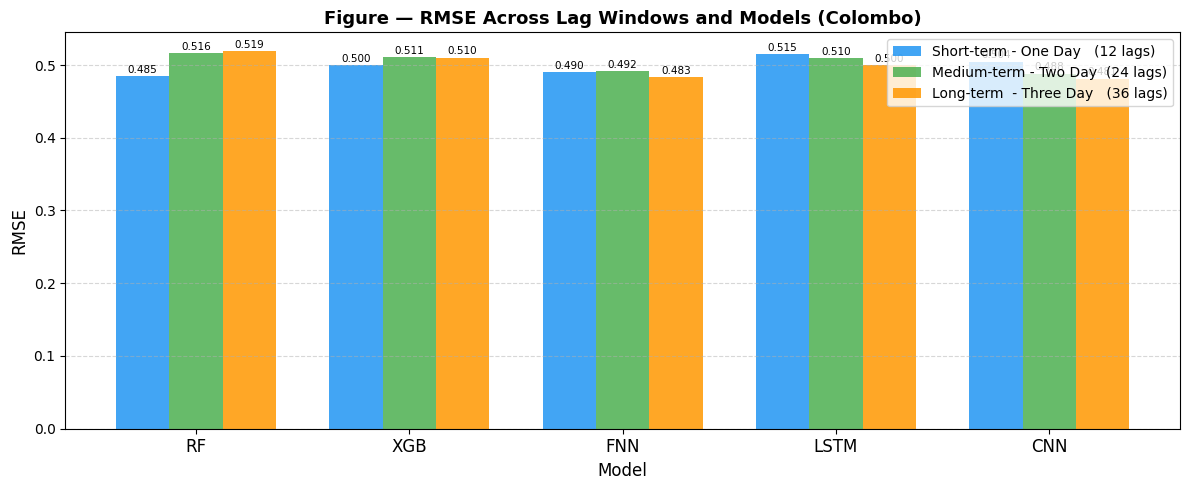

Saved → Fig_RMSE_LagWindow_Comparison.png


In [14]:
x      = np.arange(len(model_labels))
width  = 0.25
colors = ['#2196F3', '#4CAF50', '#FF9800']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (window_name, color) in enumerate(zip(window_labels, colors)):
    if window_name not in results:
        continue
    rmse_vals = [results[window_name].get(m, (0, 0))[1] for m in model_labels]
    bars = ax.bar(x + i * width, rmse_vals, width,
                  label=window_name.strip(), color=color, alpha=0.85)
    for bar, val in zip(bars, rmse_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x + width)
ax.set_xticklabels(model_labels, fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_title('Figure — RMSE Across Lag Windows and Models (Colombo)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('Fig_RMSE_LagWindow_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved → Fig_RMSE_LagWindow_Comparison.png')

## Cell 15 — Figure: R² Bar Chart

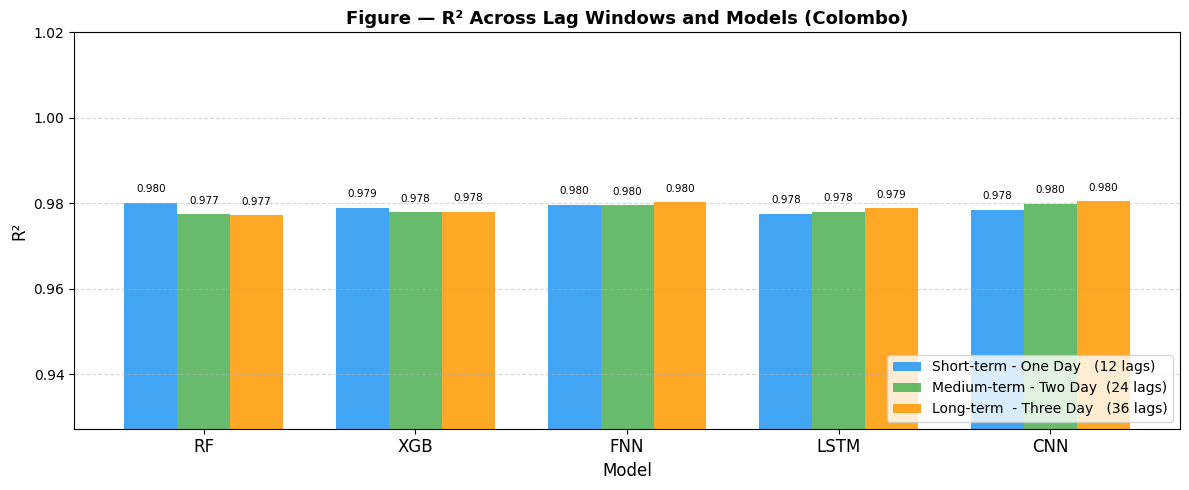

Saved → Fig_R2_LagWindow_Comparison.png


In [15]:
fig, ax2 = plt.subplots(figsize=(12, 5))
for i, (window_name, color) in enumerate(zip(window_labels, colors)):
    if window_name not in results:
        continue
    r2_vals = [results[window_name].get(m, (0, 0, 0, 0, 0))[4] for m in model_labels]
    bars = ax2.bar(x + i * width, r2_vals, width,
                   label=window_name.strip(), color=color, alpha=0.85)
    for bar, val in zip(bars, r2_vals):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)

ax2.set_xticks(x + width)
ax2.set_xticklabels(model_labels, fontsize=12)
ax2.set_ylabel('R²', fontsize=12)
ax2.set_xlabel('Model', fontsize=12)
ax2.set_title('Figure — R² Across Lag Windows and Models (Colombo)',
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=10, loc='lower right')
r2_all = [results[w].get(m, (0, 0, 0, 0, 0))[4]
          for w in window_labels if w in results for m in model_labels]
ax2.set_ylim([max(0, min(r2_all) - 0.05), 1.02])
ax2.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('Fig_R2_LagWindow_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved → Fig_R2_LagWindow_Comparison.png')

## Cell 16 — Figure: RMSE Heatmap

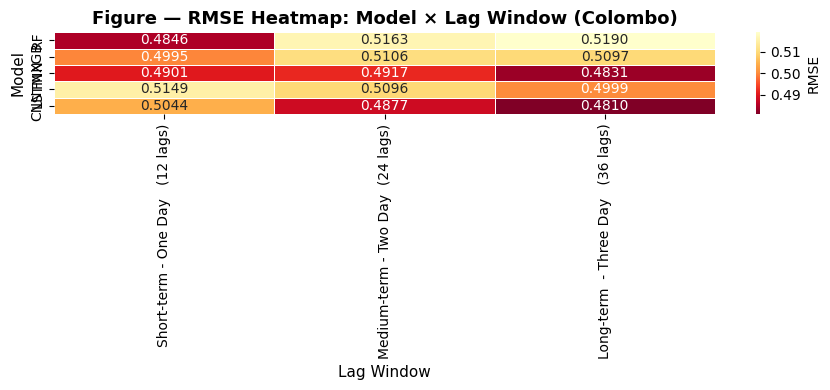

Saved → Fig_RMSE_Heatmap.png


In [16]:
rmse_matrix = pd.DataFrame(
    {window_name.strip(): [results[window_name].get(m, (0, 0))[1]
                           for m in model_labels]
     for window_name in window_labels if window_name in results},
    index=model_labels,
)

fig_hm, ax_hm = plt.subplots(figsize=(9, 4))
sns.heatmap(rmse_matrix, annot=True, fmt='.4f', cmap='YlOrRd_r',
            linewidths=0.5, ax=ax_hm, cbar_kws={'label': 'RMSE'})
ax_hm.set_title('Figure — RMSE Heatmap: Model × Lag Window (Colombo)',
                fontsize=13, fontweight='bold')
ax_hm.set_xlabel('Lag Window', fontsize=11)
ax_hm.set_ylabel('Model', fontsize=11)
plt.tight_layout()
plt.savefig('Fig_RMSE_Heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved → Fig_RMSE_Heatmap.png')

## Cell 17 — Best Model per Window

In [17]:
print('── Best Model per Window (lowest RMSE) ─────────────────────────────────')
for window_name in window_labels:
    if window_name not in results or not results[window_name]:
        continue
    rmses      = {m: results[window_name][m][1] for m in model_labels if m in results[window_name]}
    best_model = min(rmses, key=rmses.get)
    print(f'  {window_name.strip():40s}  →  {best_model}  (RMSE={rmses[best_model]:.4f})')

print()
print('── Best Model per Window (highest R²) ──────────────────────────────────')
for window_name in window_labels:
    if window_name not in results or not results[window_name]:
        continue
    r2s        = {m: results[window_name][m][4] for m in model_labels if m in results[window_name]}
    best_model = max(r2s, key=r2s.get)
    print(f'  {window_name.strip():40s}  →  {best_model}  (R²={r2s[best_model]:.4f})')

── Best Model per Window (lowest RMSE) ─────────────────────────────────
  Short-term - One Day   (12 lags)          →  RF  (RMSE=0.4846)
  Medium-term - Two Day  (24 lags)          →  CNN  (RMSE=0.4877)
  Long-term  - Three Day   (36 lags)        →  CNN  (RMSE=0.4810)

── Best Model per Window (highest R²) ──────────────────────────────────
  Short-term - One Day   (12 lags)          →  RF  (R²=0.9801)
  Medium-term - Two Day  (24 lags)          →  CNN  (R²=0.9799)
  Long-term  - Three Day   (36 lags)        →  CNN  (R²=0.9804)


## Cell 18 — Actual vs Predicted Time-Series Plots

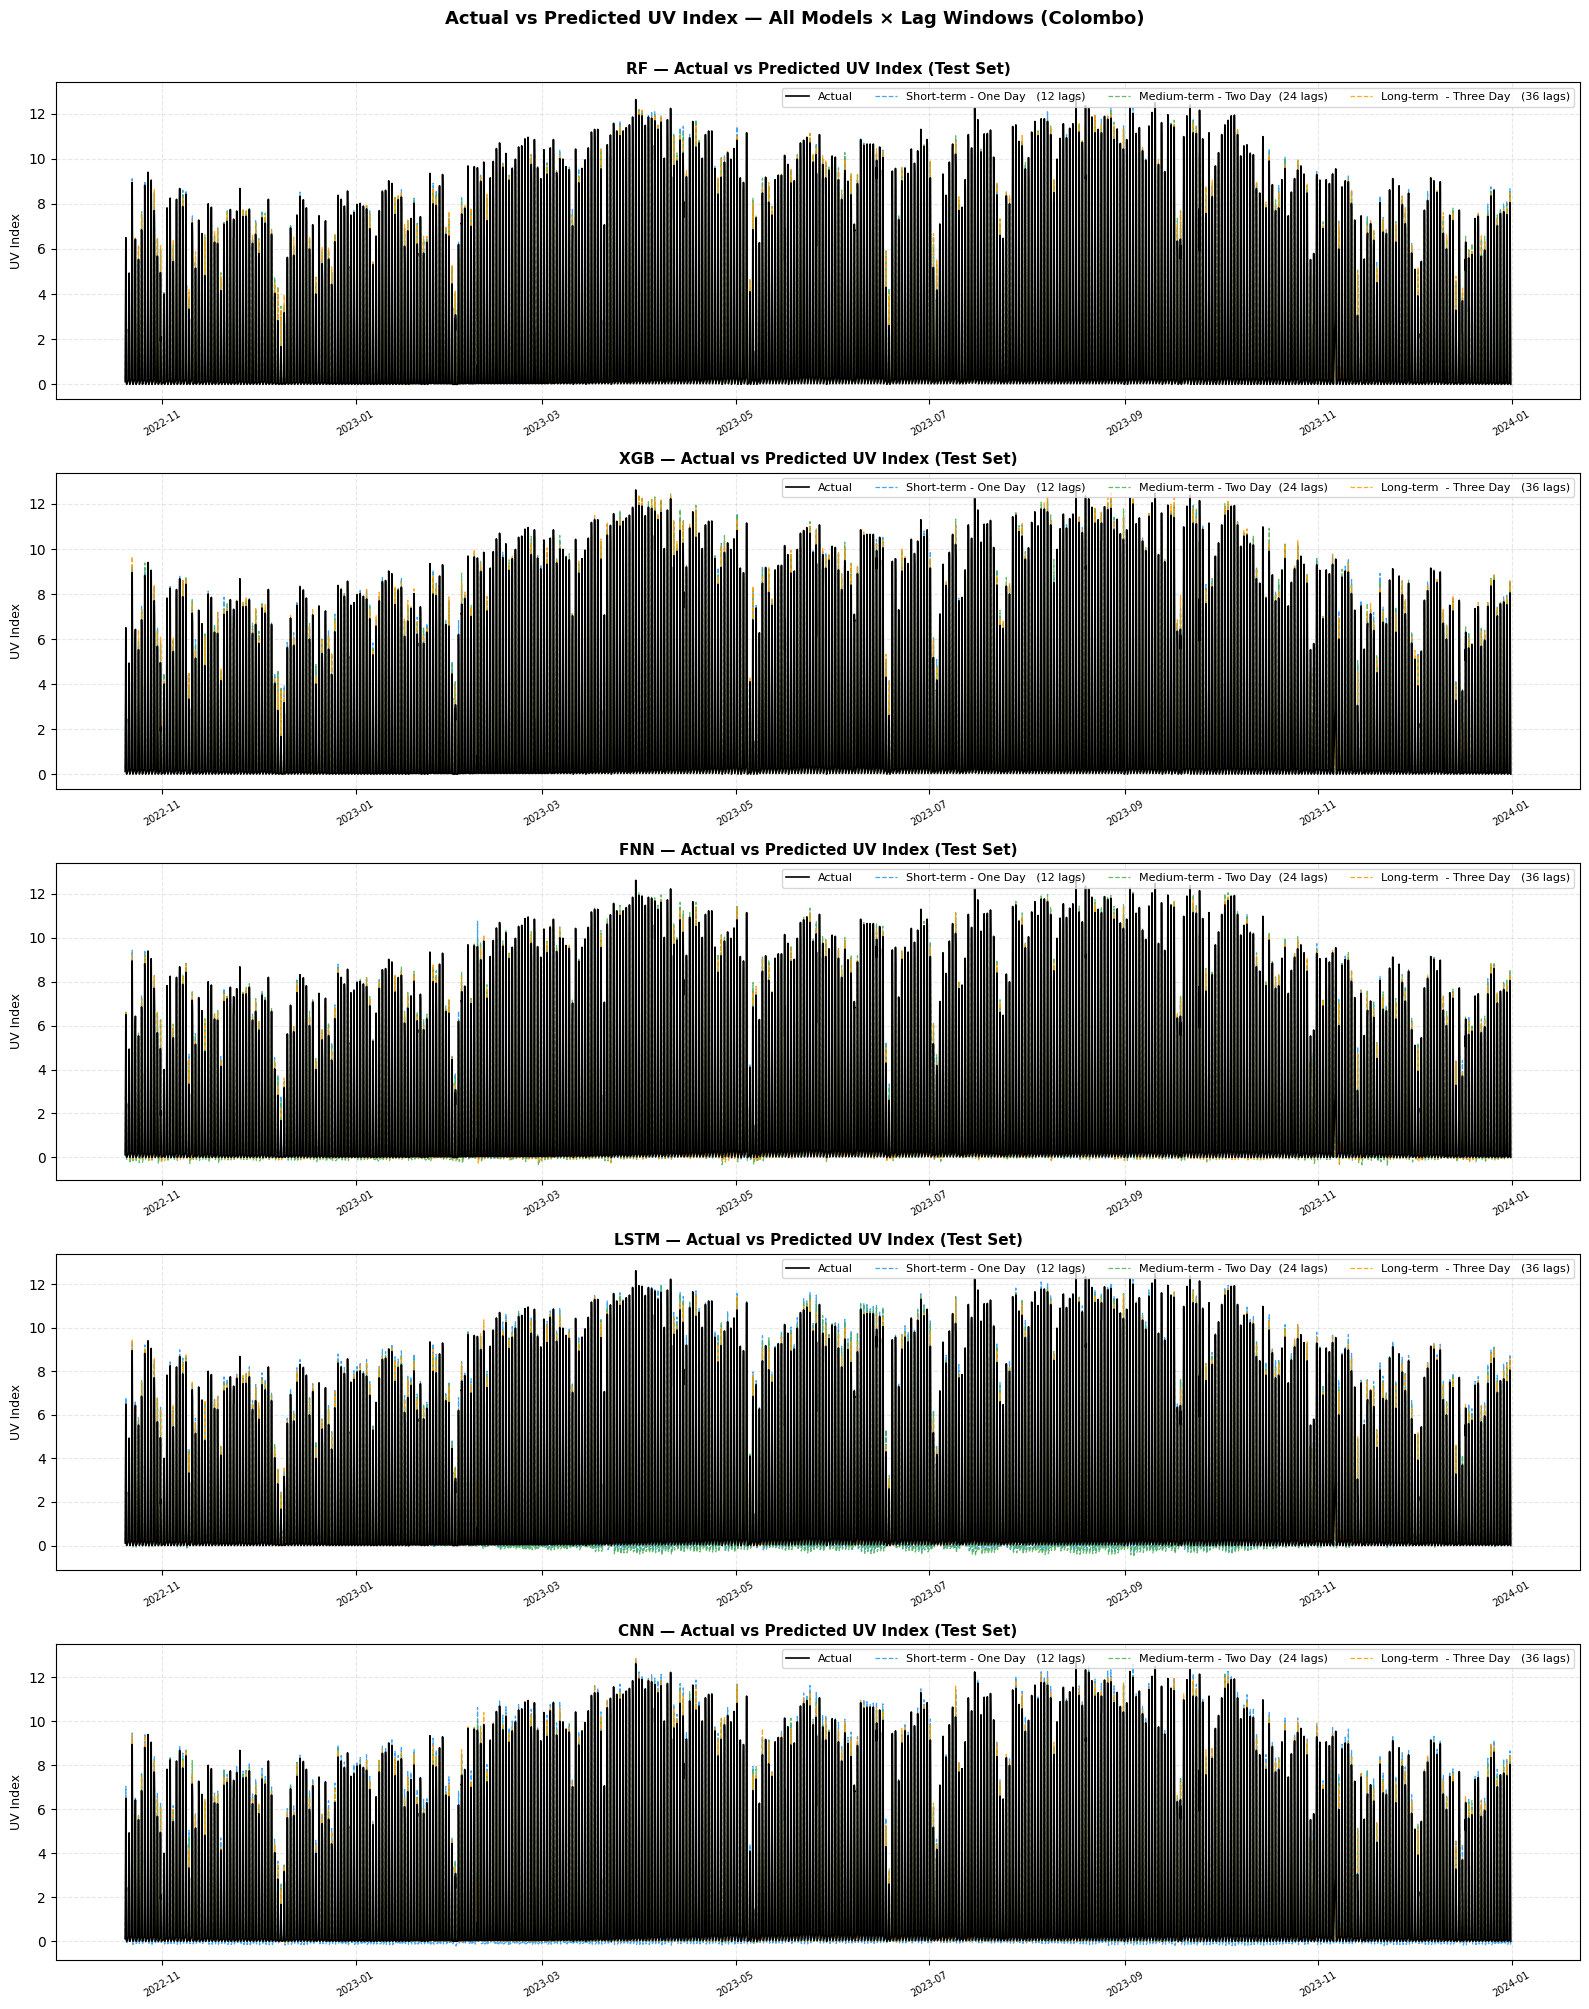

Saved → Fig_ActualVsPredicted_AllModels.png


In [18]:
window_palette = {
    window_labels[0]: '#2196F3',
    window_labels[1]: '#4CAF50',
    window_labels[2]: '#FF9800',
}

available_models = [m for m in model_labels
                    if any(m in results.get(w, {}) for w in window_labels)]

fig, axes = plt.subplots(len(available_models), 1,
                         figsize=(16, 4 * len(available_models)),
                         sharex=False)
if len(available_models) == 1:
    axes = [axes]

for ax, model_name in zip(axes, available_models):
    first = True
    for window_name in window_labels:
        if model_name not in predictions.get(window_name, {}):
            continue
        y_test, y_pred = predictions[window_name][model_name]
        color = window_palette[window_name]
        if first:
            ax.plot(y_test.index, y_test.values,
                    color='black', linewidth=1.2, label='Actual', zorder=5)
            first = False
        ax.plot(y_test.index, y_pred, color=color, linewidth=0.9,
                linestyle='--', alpha=0.85, label=window_name.strip())
    ax.set_title(f'{model_name} — Actual vs Predicted UV Index (Test Set)',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('UV Index', fontsize=9)
    ax.legend(fontsize=8, loc='upper right', ncol=4)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.tick_params(axis='x', labelsize=7, rotation=30)

plt.suptitle('Actual vs Predicted UV Index — All Models × Lag Windows (Colombo)',
             fontsize=13, fontweight='bold', y=1.002)
plt.tight_layout()
plt.savefig('Fig_ActualVsPredicted_AllModels.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved → Fig_ActualVsPredicted_AllModels.png')

## Cell 19 — Export Results CSV

In [ ]:
export_rows = []
for window_name in window_labels:
    for model_name in model_labels:
        if model_name not in results.get(window_name, {}):
            continue
        m = results[window_name][model_name]
        export_rows.append({
            'Window' : window_name.strip(),
            'N_Lags' : LAG_WINDOWS[window_name],
            'Model'  : model_name,
            'MSE'    : round(m[0], 6),
            'RMSE'   : round(m[1], 6),
            'MAE'    : round(m[2], 6),
            'MAPE'   : round(m[3], 4),
            'R2'     : round(m[4], 6),
        })

results_df = pd.DataFrame(export_rows)
results_df.to_csv('Table3_Colombo_LagWindow_Results.csv', index=False)
print('Saved → Table3_Colombo_LagWindow_Results.csv\n')
print(results_df.to_string(index=False))

---
## Utility — Clear All Checkpoints (run only if you want to retrain from scratch)

In [20]:
# ⚠️  Uncomment and run ONLY if you want to delete all saved checkpoints and retrain

# import glob
# for f in glob.glob('checkpoint/*.pkl'):
#     os.remove(f)
#     print(f'Deleted: {f}')
# print('All checkpoints cleared — re-run Cells 5–9 to retrain.')